In [1]:
#!pip -q install numpy pandas matplotlib scikit-learn tqdm vector
#!pip install --upgrade gdown

import sys
import importlib
import os
import urllib.request
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
import glob
import gc
import pylhe



# Force-download the newest version of the helper file
!wget -q -O helpers.py https://raw.githubusercontent.com/andlessa/UnfoldingBSMttbar/main/helpers.py

# Import the module and force Python to clear cache and reload it
import helpers as hp
importlib.reload(hp)

# Global Plotting Configuration
plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 12, "axes.labelsize": 14, "axes.titlesize": 14,
    "legend.fontsize": 11, "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.linewidth": 1.0, "lines.linewidth": 2.2, "lines.markersize": 4.5,
    "legend.frameon": False, "mathtext.fontset": "cm",
})

# Dictionaries for styling
pair_colors = {"Scalar vs VLF": "#1f77b4", "Scalar vs Zprime": "#2ca02c", "VLF vs Zprime": "#d62728"}
class_colors = {"Scalar": "#1f77b4", "VLF": "#ff7f0e", "Zprime": "#2ca02c"}
pair_latex = {"Scalar vs VLF": r"Scalar vs VLF", "Scalar vs Zprime": r"Scalar vs $Z^\prime$", "VLF vs Zprime": r"VLF vs $Z^\prime$"}
class_latex = {"Scalar": r"Scalar", "VLF": r"VLF", "Zprime": r"$Z^\prime$"}
syst_styles = {0.00: ("black", "-"), 0.02: ("#1f77b4", "--"), 0.05: ("#ff7f0e", "-."), 0.10: ("#d62728", ":")}
eps_styles = {
    0.0: ('-', 'D'),
    0.02: ("-.", "o"),
    0.05: ("--", "s"),
    0.10: (":", "^")
}

In [5]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import pylhe
from tqdm import tqdm

# --- LHAPDF Path Setup ---
# Replace with your actual LHAPDF installation path if different
sys.path.append("/home/vinicius/MG5/HEPTools/lhapdf6_py3/lib/python3.14/dist-packages")
import lhapdf

# ==========================================
# 1. CONFIGURATION & MODEL REGISTRY SETUP
# ==========================================
E_BEAM = 6500.0    # Beam energy in GeV (e.g., 6500 for 13 TeV LHC)
PDF_NAME = 244600  # Must match the PDF set used in your MG5 event generation

# Fixed Renormalization & Factorization Scale 
MU_F  = 91.188     # Factorization scale in GeV (used ONLY for LHAPDF parton densities)
MU_R  = 91.188    # Renormalization scale in GeV (used for LHAPDF alpha_s)
MU_R2 = MU_R**2    # Renormalization scale squared in GeV^2 (used for MadLoop virtuals)   # Scale squared in GeV^2 (used for MadLoop virtuals)

# Define absolute root paths for all 3 model hypotheses
MODEL_ROOTS = {
    "VLF":    os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses"),
    "Scalar": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/SMS_1_loop/MatrixElements/SubProcesses"),
    "Zprime": os.path.abspath("/home/vinicius/EFT_ToyModel/processFolders/z_prime/MatrixElements/SubProcesses")
}

# Define production channels (using P1_ indexing for Zprime as confirmed earlier)
MODEL_CHANNELS = {
    "VLF":    ["P0_uux_ttx", "P2_gg_ttx"],
    "Scalar": ["P0_uux_ttx", "P2_gg_ttx"],
    "Zprime": [
        "P1_uux_ttx", 
        "P1_ccx_ttx", 
        "P1_ddx_ttx", 
        "P1_ssx_ttx", 
        "P1_gg_ttx"
    ]
}

# Map MadGraph directory prefixes to their corresponding PDG quark IDs for PDF lookup
PDG_MAP = {
    "uux": 2,  # Up
    "ddx": 1,  # Down
    "ssx": 3,  # Strange
    "ccx": 4,  # Charm
    "bbx": 5   # Bottom
}

# ==========================================
# 2. UNIVERSAL LIBRARY LOADER & INITIALIZER
# ==========================================
def init_model_card(module, subproc_path, module_label):
    """Dynamically detects and calls the correct Fortran initialization routine."""
    card_path = os.path.abspath(os.path.join(subproc_path, "..", "..", "Cards", "param_card.dat"))
    if not os.path.exists(card_path):
        raise FileNotFoundError(f"[{module_label}] Could not find parameter card at: {card_path}")
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        mod_attrs = dir(module)
        lo_init = [a for a in mod_attrs if a.endswith('initialisemodel')]
        nlo_init = [a for a in mod_attrs if 'initialise' in a and not a.endswith('initialisemodel')]
        
        if lo_init:
            getattr(module, lo_init[0])(card_path)
        elif nlo_init:
            getattr(module, nlo_init[0])(card_path)
        else:
            raise AttributeError(f"[{module_label}] No valid initialization subroutine found!")
    finally:
        os.chdir(original_cwd)

def load_all_models(roots_dict, channels_dict):
    """Loads and compiles all matrix_*.so libraries into a unified dictionary registry."""
    registry = {}
    print("Loading Matrix Element Libraries...\n" + "="*50)
    for model_name, root_dir in roots_dict.items():
        print(f" -> Loading Model: [{model_name}]")
        registry[model_name] = {}
        for channel in channels_dict[model_name]:
            subproc_path = os.path.join(root_dir, channel)
            if subproc_path not in sys.path:
                sys.path.append(subproc_path)
            
            so_files = glob.glob(os.path.join(subproc_path, f"*matrix_{model_name}*.so")) or \
                       glob.glob(os.path.join(subproc_path, "*matrix*.so"))
            if not so_files:
                raise FileNotFoundError(f"No compiled .so library found in {subproc_path}")
            
            so_path = so_files[0]
            lib_name = os.path.basename(so_path).split(".")[0]  # Strip architecture tags
            
            spec = importlib.util.spec_from_file_location(lib_name, so_path)
            mod = importlib.util.module_from_spec(spec)
            sys.modules[lib_name] = mod
            spec.loader.exec_module(mod)
            
            init_model_card(mod, subproc_path, f"{model_name} | {channel}")
            registry[model_name][channel] = {
                "module": mod,
                "path": subproc_path
            }
            print(f"    [✓] {channel}")
    print("="*50 + "\n")
    return registry

# Initialize global model registry
models = load_all_models(MODEL_ROOTS, MODEL_CHANNELS)

# ==========================================
# 3. UNIVERSAL MATRIX ELEMENT EVALUATOR
# ==========================================
def eval_full_me(module_dict, p_fortran, alphas, scale2, nhel=-1):
    """
    Evaluates the FULL finite matrix element across both LO and NLO libraries.
    For NLO/Loop models, this sums the Born term and the finite 1-loop correction
    to capture your full BSM squared order limits.
    For LO models (e.g., Z prime), it returns only the Born term.
    """
    mod = module_dict["module"]
    subproc_path = module_dict["path"]
    mod_attrs = dir(mod)
    
    lo_eval = [a for a in mod_attrs if a.endswith('get_value')]
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        # Step into subprocess directory so Fortran reads local auxiliary filter files safely
        os.chdir(subproc_path)
        
        # --- CASE 1: LEADING ORDER (Tree-Level, e.g., Z prime) ---
        if lo_eval:
            val = getattr(mod, lo_eval[0])(p_fortran, alphas, nhel)
            val_list = [float(x) for x in np.ravel(val)]
            # Leading Order is pure tree-level, no loop terms to sum
            return val_list[0] if len(val_list) > 0 else 0.0
            
        # --- CASE 2: NEXT-TO-LEADING ORDER / LOOP (e.g., VLF, Scalar) ---
        elif nlo_eval:
            res, _ = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
            res_list = [float(x) for x in np.ravel(res)]
            
            if len(res_list) == 4:
                # Patched Wrapper! Array is exactly [Born, Finite, 1eps, 2eps]
                born_val   = res_list[0]
                finite_val = res_list[1]
                return born_val + finite_val
            else:
                # Unpatched Wrapper (Original MadGraph). 
                # Born is not exported, res_list[0] is the Finite term!
                finite_val = res_list[0] if len(res_list) > 0 else 0.0
                return finite_val
                
        else:
            raise AttributeError("Module does not define get_value or get_me!")
            
    finally:
        os.chdir(original_cwd)

Loading Matrix Element Libraries...
 -> Loading Model: [VLF]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Scalar]
    [✓] P0_uux_ttx
    [✓] P2_gg_ttx
 -> Loading Model: [Zprime]
    [✓] P1_uux_ttx
    [✓] P1_ccx_ttx
    [✓] P1_ddx_ttx
    [✓] P1_ssx_ttx
    [✓] P1_gg_ttx



In [23]:


# ==========================================
# 4. MAIN LIKELIHOOD COMPUTATION LOOP
# ==========================================
def compute_matrix_elements(lhe_path, output_csv_path=None):
    print(f"Processing LHE file: {lhe_path}")
    print(f"Initializing LHAPDF with set {PDF_NAME}...")
    
    # --- THE FIX: Separate integer ID loading from string name loading ---
    if isinstance(PDF_NAME, int):
        pdf = lhapdf.mkPDF(PDF_NAME)
    else:
        pdf = lhapdf.mkPDF(str(PDF_NAME), 0)
    
    try:
        total_events = pylhe.read_num_events(lhe_path)
    except Exception:
        total_events = None

    events = pylhe.read_lhe_with_attributes(lhe_path)
    results = []
    
    for idx, event in enumerate(tqdm(events, total=total_events, desc="Computing MEM Likelihoods")):
        outgoing = [p for p in event.particles if p.status == 1]
        if len(outgoing) != 2:
            continue
            
        # Ensure strict ordering: [Top (6), Anti-Top (-6)]
        outgoing = sorted(outgoing, key=lambda x: x.id, reverse=True)
        t, tbar = outgoing[0], outgoing[1]
        
        # --- Kinematic Reconstruction ---
        # --- Kinematic Reconstruction ---
        E_tt  = t.e + tbar.e
        pz_tt = t.pz + tbar.pz
        x1 = (E_tt + pz_tt) / (2.0 * E_BEAM)
        x2 = (E_tt - pz_tt) / (2.0 * E_BEAM)
        
        if not (0 < x1 < 1.0 and 0 < x2 < 1.0):
            continue
            
        px_tt = t.px + tbar.px
        py_tt = t.py + tbar.py
        s_hat = E_tt**2 - px_tt**2 - py_tt**2 - pz_tt**2
        
        # --- THE FIX: Assign independent scales ---
        alphas = pdf.alphasQ(MU_R)  # Strong coupling evaluated at the renormalization scale
        
        # Pre-compute Gluon PDF weight at the FACTORIZATION scale (MU_F)
        w_gg = (pdf.xfxQ(21, x1, MU_F) / x1) * (pdf.xfxQ(21, x2, MU_F) / x2)
        
        # Format 4-momenta aligned on z-axis for MadGraph evaluation
        p1 = [x1 * E_BEAM, 0.0, 0.0,  x1 * E_BEAM]
        p2 = [x2 * E_BEAM, 0.0, 0.0, -x2 * E_BEAM]
        p_list = [p1, p2, [t.e, t.px, t.py, t.pz], [tbar.e, tbar.px, tbar.py, tbar.pz]]
        P_fortran = np.asfortranarray(invert_momenta(p_list), dtype=np.float64)
        
        # --- Model Hypothesis Likelihood Evaluation ---
        event_record = {
            "Event": idx,
            "x1": x1,
            "x2": x2,
            "s_hat": s_hat,
            "alphas": alphas,
            "w_gg": w_gg
        }
        
        try:
            # Loop dynamically over VLF, Scalar, and Zprime models
            for model_name, channels in models.items():
                likelihood_total = 0.0
                
                for ch_name, mod_data in channels.items():
                    # Pass MU_R2 (Renormalization scale squared) into Fortran!
                    me_val = eval_full_me(mod_data, P_fortran, alphas, MU_R2, -1)
                    
                    if "gg" in ch_name:
                        likelihood_total += w_gg * me_val
                    else:
                        q_str = next((k for k in PDG_MAP.keys() if k in ch_name), "uux")
                        q_id = PDG_MAP[q_str]
                        
                        # Compute flavor-specific PDF weight at the FACTORIZATION scale (MU_F)
                        fq_1    = pdf.xfxQ(q_id, x1, MU_F) / x1
                        fqbar_2 = pdf.xfxQ(-q_id, x2, MU_F) / x2
                        fqbar_1 = pdf.xfxQ(-q_id, x1, MU_F) / x1
                        fq_2    = pdf.xfxQ(q_id, x2, MU_F) / x2
                        
                        w_qq_flavor = (fq_1 * fqbar_2) + (fqbar_1 * fq_2)
                        likelihood_total += w_qq_flavor * me_val
                
                event_record[f"L_{model_name}"] = likelihood_total
                
            results.append(event_record)
            
        except Exception as e:
            tqdm.write(f"Error computing ME for event {idx}: {e}")
            continue

    df = pd.DataFrame(results).dropna().reset_index(drop=True)
    print(f"\nSuccessfully computed MEM likelihoods for {len(df)} events.")
    
    # Save directly to disk if an output path is provided
    if output_csv_path:
        df.to_csv(output_csv_path, index=False, compression='infer')
        print(f"Saved likelihood dataframe to: {output_csv_path}")
        
    return df

# --- Execution Example ---
lhe_file_path = "/home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_tunning_1000_900/events.lhe.gz"
output_file   = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz"

df_mem = compute_matrix_elements(lhe_file_path, output_csv_path=output_file)
print(df_mem.head())

Processing LHE file: /home/vinicius/UnfoldingBSMttbar/processFolders/Scalar/pp2ttbar_gs4_ydm2/Events/bias_tunning_1000_900/events.lhe.gz
Initializing LHAPDF with set 244600...
LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600


Computing MEM Likelihoods: 100%|██| 3681001/3681001 [1:42:47<00:00, 596.88it/s]



Successfully computed MEM likelihoods for 3681001 events.
Saved likelihood dataframe to: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz
   Event        x1        x2         s_hat    alphas       w_gg     L_VLF  \
0      0  0.058796  0.225580  2.241500e+06  0.088464  27.340552  0.010679   
1      1  0.042263  0.251286  1.794807e+06  0.088464  36.513411  0.011401   
2      2  0.050606  0.204870  1.752118e+06  0.088464  51.970040  0.015361   
3      3  0.015541  0.795728  2.089883e+06  0.088464  -0.021132  0.000059   
4      4  0.061587  0.212136  2.207940e+06  0.088464  30.563422  0.011435   

   L_Scalar    L_Zprime  
0 -0.006527  388.039593  
1 -0.007713  430.919505  
2 -0.013398  632.045903  
3  0.000047    0.443777  
4 -0.007513  425.533001  


Loading likelihood data from: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz
Processing 3,681,001 events for plotting...
Plot successfully saved to: /home/vinicius/UnfoldingBSMttbar/Scalar_vs_VLF_LogLikelihood.png


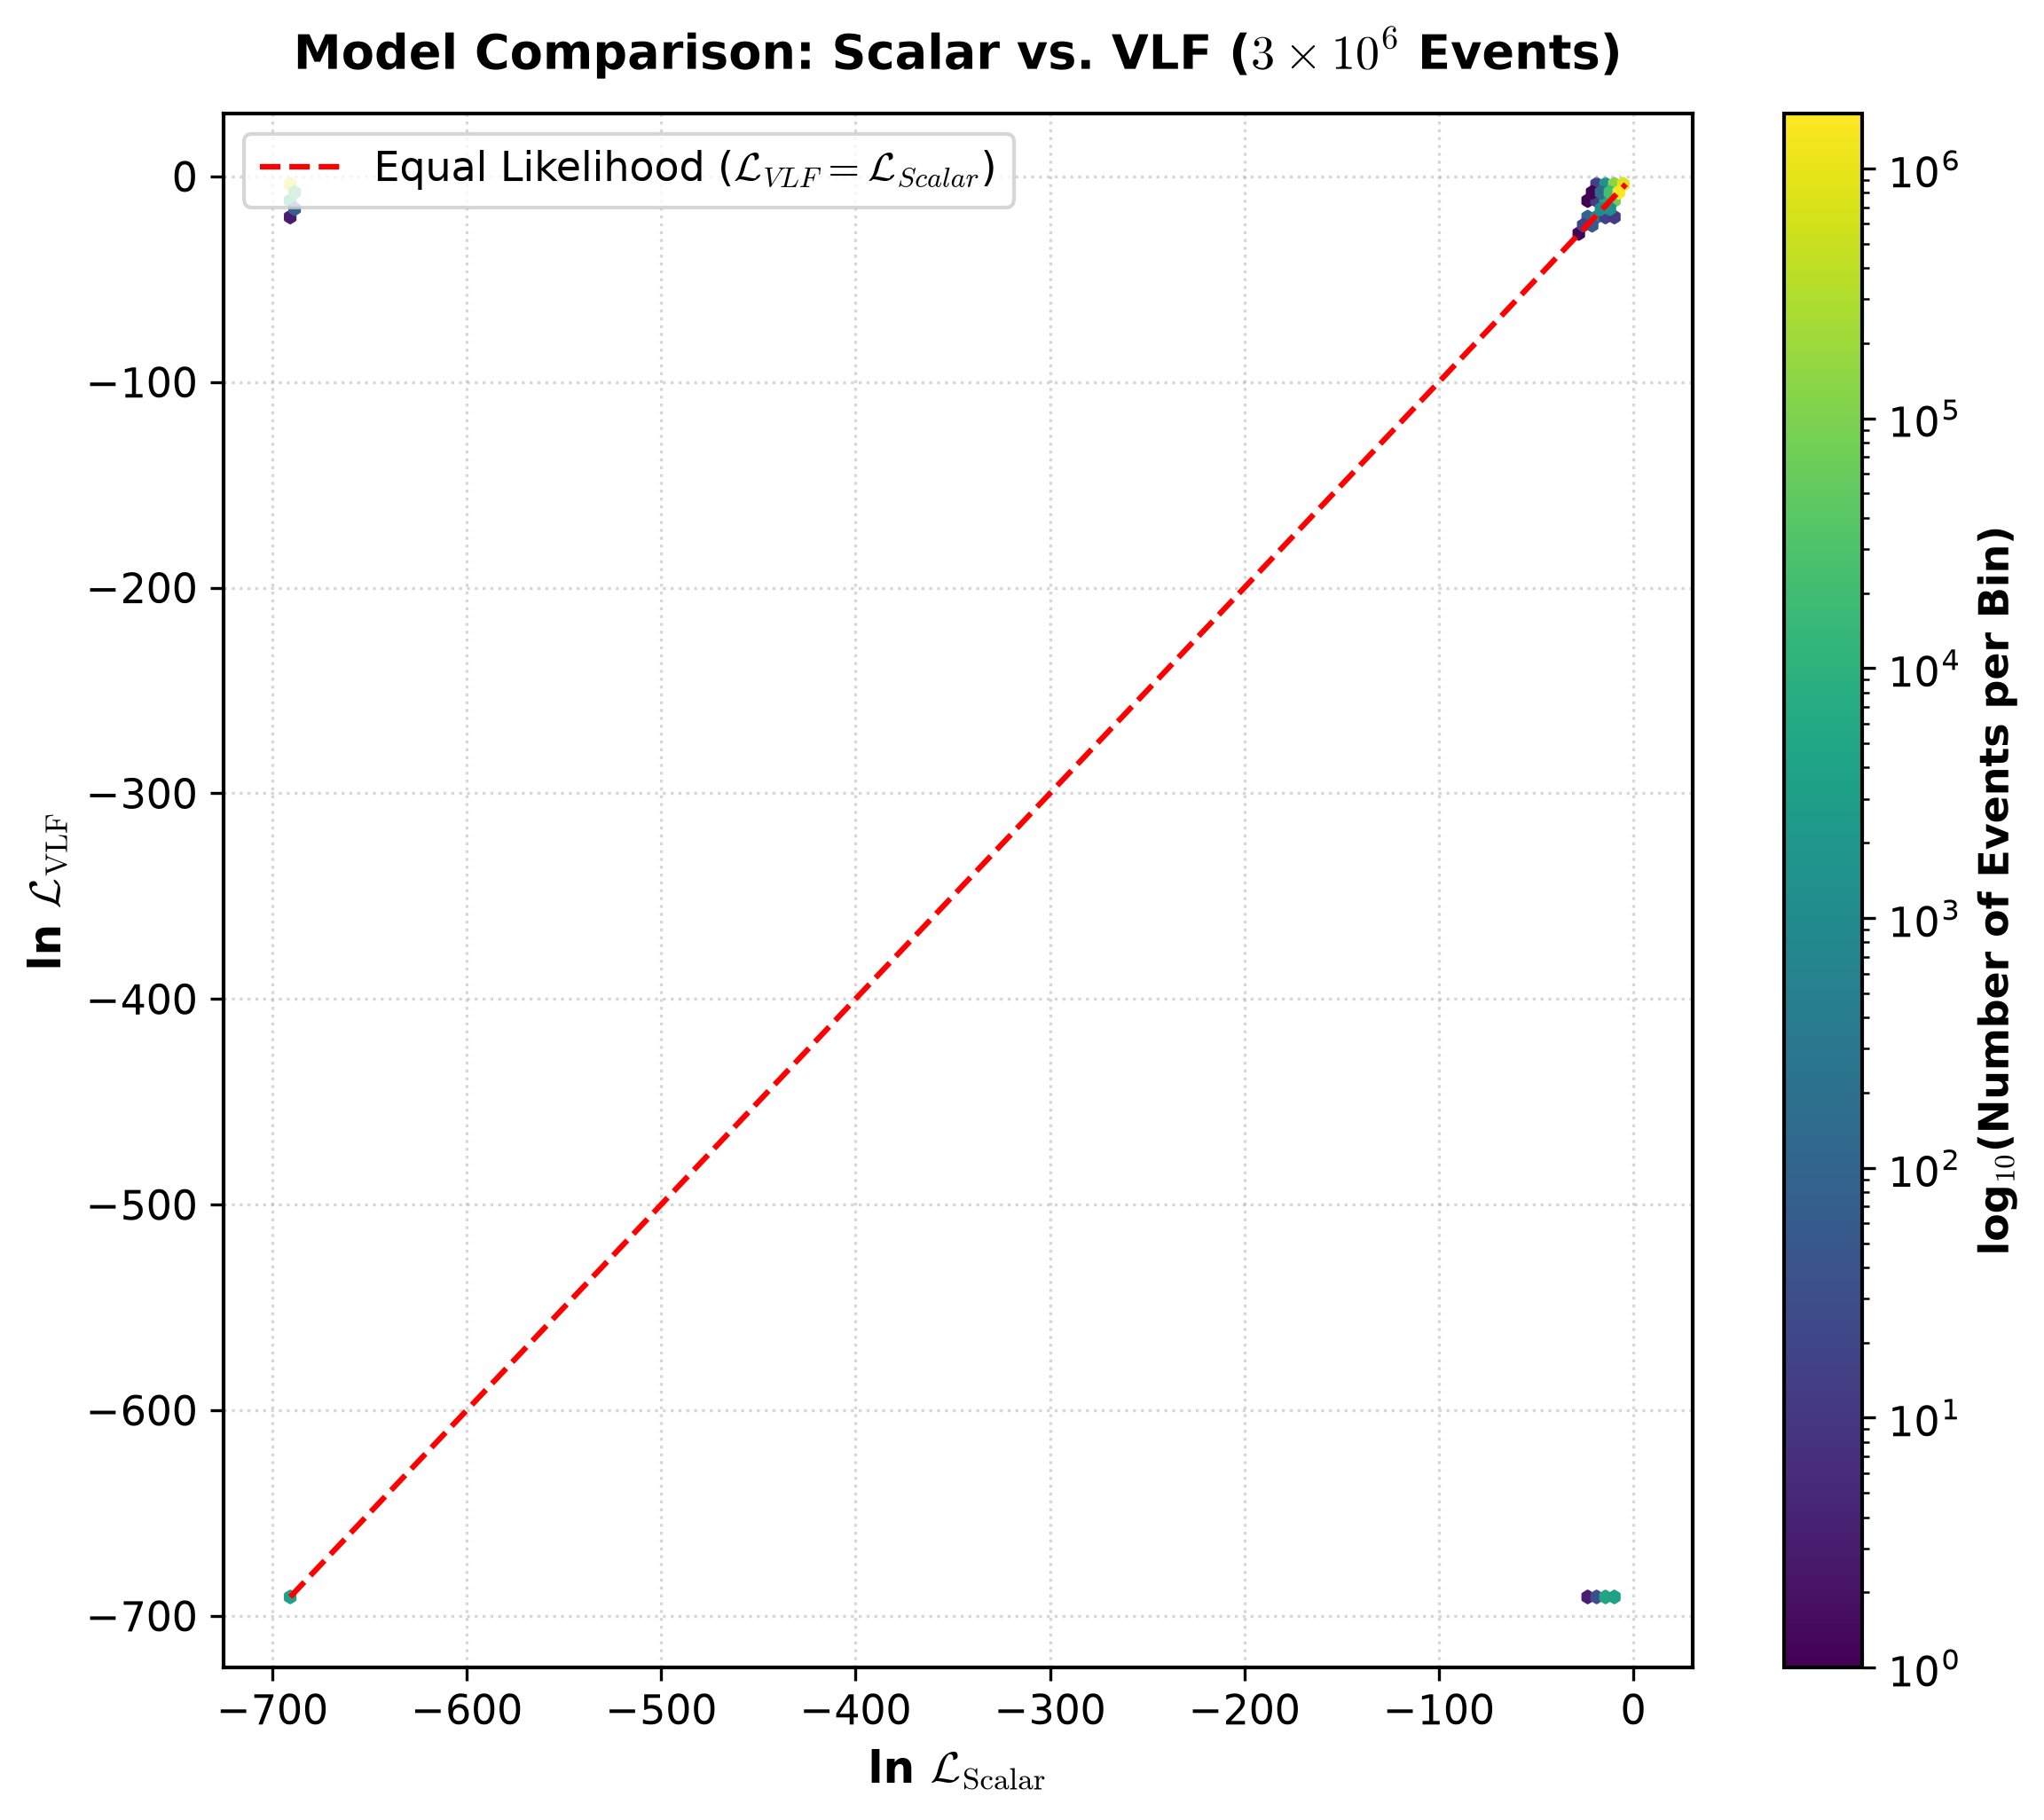

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD THE LIKELIHOOD DATAFRAME
# ==========================================
csv_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz"
print(f"Loading likelihood data from: {csv_path}")

# Read the compressed CSV file
df = pd.read_csv(csv_path)

# ==========================================
# 2. COMPUTE LOG-LIKELIHOODS
# ==========================================
# We use a small epsilon (or handle zeros safely) just in case 
# any unphysical numerical likelihood evaluated strictly to 0.0
eps = 1e-300

df['logL_Scalar'] = np.log(np.maximum(df['L_Scalar'], eps))
df['logL_VLF']    = np.log(np.maximum(df['L_VLF'], eps))

# Drop any potential NaN/infinite values resulting from extreme fluctuations
df_clean = df.dropna(subset=['logL_Scalar', 'logL_VLF'])
print(f"Processing {len(df_clean):,} events for plotting...")

# ==========================================
# 3. GENERATE 2D HEXBIN DENSITY PLOT
# ==========================================
plt.figure(figsize=(8, 7), dpi=300)

# Hexbin aggregates 3M points into hexagonal bins colored by density
hb = plt.hexbin(
    df_clean['logL_Scalar'], 
    df_clean['logL_VLF'], 
    gridsize=150,               # Resolution of the grid (higher = finer hexagons)
    cmap='viridis',             # Perceptually uniform colormap
    bins='log',                 # Logarithmic color scaling to handle wide density variations
    mincnt=1                    # Hide empty bins (leaves background clean white)
)

# Add a professional colorbar indicating event counts per bin
cb = plt.colorbar(hb)
cb.set_label('log$_{10}$(Number of Events per Bin)', fontsize=11, fontweight='bold')

# ==========================================
# 4. FORMATTING AND DIAGONAL REFERENCE LINE
# ==========================================
plt.xlabel(r'ln $\mathcal{L}_{\text{Scalar}}$', fontsize=12, fontweight='bold')
plt.ylabel(r'ln $\mathcal{L}_{\text{VLF}}$', fontsize=12, fontweight='bold')
plt.title(r'Model Comparison: Scalar vs. VLF ($3\times 10^6$ Events)', fontsize=13, fontweight='bold', pad=12)

# Optional: Draw a 1-to-1 diagonal reference line (y = x)
# Points above this line favor VLF; points below favor Scalar
min_val = min(df_clean['logL_Scalar'].min(), df_clean['logL_VLF'].min())
max_val = max(df_clean['logL_Scalar'].max(), df_clean['logL_VLF'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='Equal Likelihood ($\mathcal{L}_{VLF} = \mathcal{L}_{Scalar}$)')

plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

# Save high-resolution vector and raster formats for your thesis or presentation
output_plot_path = "/home/vinicius/UnfoldingBSMttbar/Scalar_vs_VLF_LogLikelihood.png"
plt.tight_layout()
plt.savefig(output_plot_path, dpi=300)
print(f"Plot successfully saved to: {output_plot_path}")

plt.show()

Loading dataset from: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz
Total events: 3,681,001
Valid positive phase-space events: 2,688,148 (Dropped 992,853 unphysical/negative rows)

--- Summary of Test Statistics ---
       LLR_VLF_vs_Scalar  LLR_Zprime_vs_Scalar
count       2.688148e+06          2.688148e+06
mean        9.131519e-01          1.030747e+01
std         8.451883e-01          1.215388e+00
min        -9.463794e+00          1.379299e+00
25%         3.687293e-01          9.351999e+00
50%         6.795281e-01          1.014340e+01
75%         1.183214e+00          1.094833e+01
max         1.447022e+01          2.460776e+01

Saved updated LLR dataframe to: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz
Saved LLR distribution plot to: /home/vinicius/UnfoldingBSMttbar/Hypothesis_Test_LLR_Distributions.png


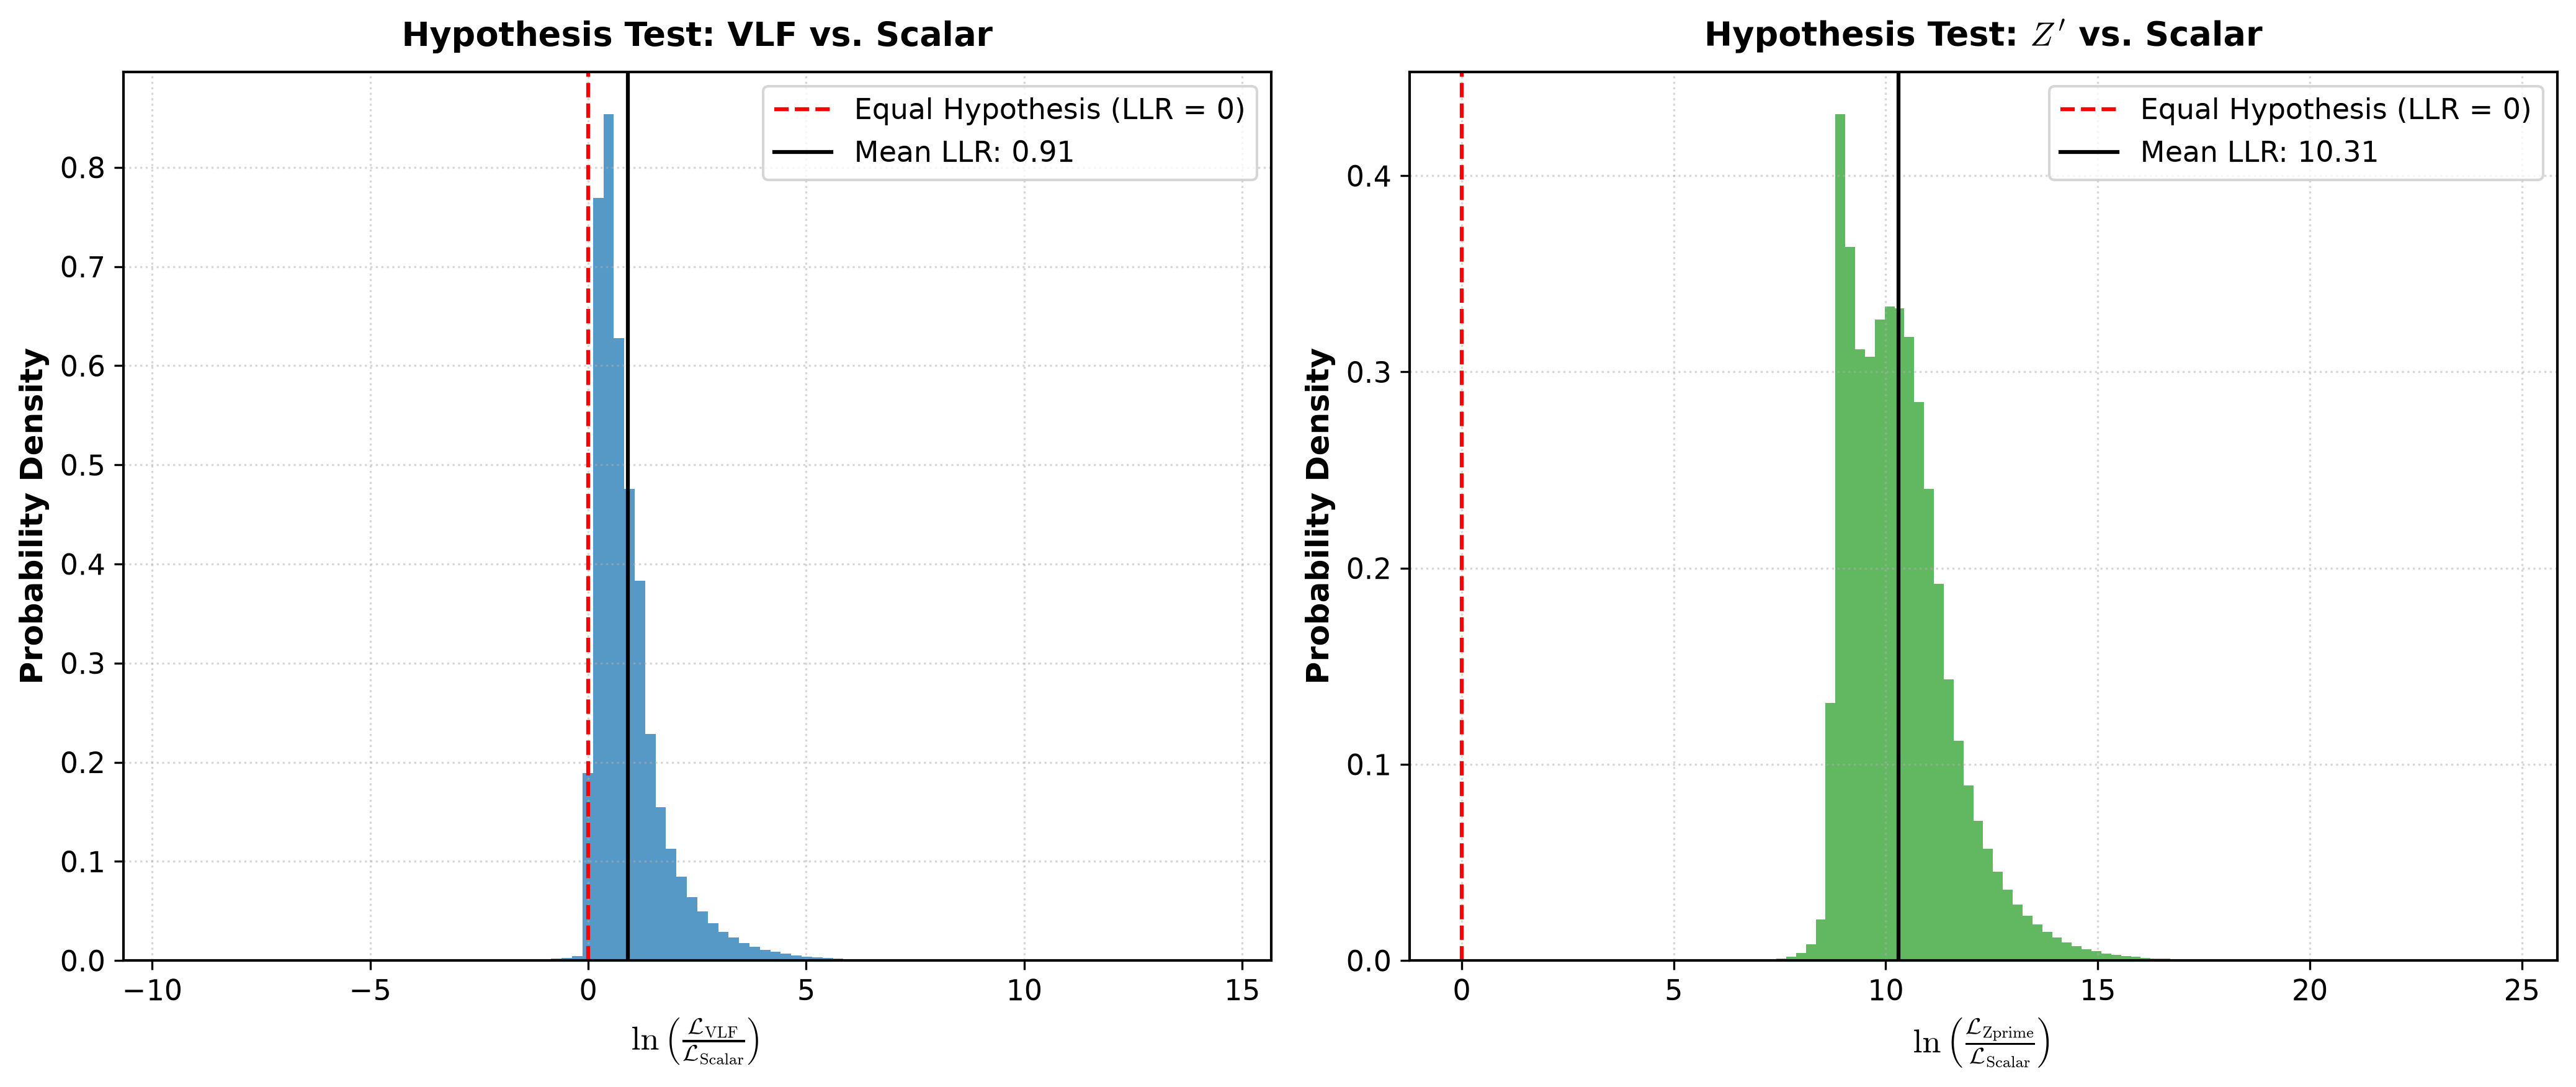

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD THE DATA
# ==========================================
csv_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_AllModels.csv.gz"
print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

# ==========================================
# 2. DATA CLEANING & POSITIVITY FILTER
# ==========================================
# Logarithms are undefined for L <= 0. In 1-loop calculations, local NLO interference
# can produce small negative weights. We filter to retain only strictly positive, physical phase space.
initial_count = len(df)
valid_mask = (df['L_Scalar'] > 0) & (df['L_VLF'] > 0) & (df['L_Zprime'] > 0)
df_clean = df[valid_mask].copy()

dropped_count = initial_count - len(df_clean)
print(f"Total events: {initial_count:,}")
print(f"Valid positive phase-space events: {len(df_clean):,} (Dropped {dropped_count:,} unphysical/negative rows)")

# ==========================================
# 3. COMPUTE LOG-LIKELIHOOD RATIOS (LLR)
# ==========================================
# Using ln(A/B) = ln(A) - ln(B) for numerical precision
df_clean['logL_Scalar'] = np.log(df_clean['L_Scalar'])
df_clean['logL_VLF']    = np.log(df_clean['L_VLF'])
df_clean['logL_Zprime'] = np.log(df_clean['L_Zprime'])

# Test Statistics: Testing Models against the Scalar hypothesis
df_clean['LLR_VLF_vs_Scalar']    = df_clean['logL_VLF'] - df_clean['logL_Scalar']
df_clean['LLR_Zprime_vs_Scalar'] = df_clean['logL_Zprime'] - df_clean['logL_Scalar']

# Display summary statistics of the test statistics
print("\n--- Summary of Test Statistics ---")
print(df_clean[['LLR_VLF_vs_Scalar', 'LLR_Zprime_vs_Scalar']].describe())

# Save the updated dataframe with LLR columns for downstream analysis
output_csv = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz"
df_clean.to_csv(output_csv, index=False, compression='infer')
print(f"\nSaved updated LLR dataframe to: {output_csv}")

# ==========================================
# 4. VISUALIZE THE LLR DISTRIBUTIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)

# --- Plot 1: VLF vs Scalar ---
ax1 = axes[0]
ax1.hist(df_clean['LLR_VLF_vs_Scalar'], bins=100, color='#1f77b4', alpha=0.75, density=True, edgecolor='none')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal Hypothesis (LLR = 0)')
ax1.axvline(df_clean['LLR_VLF_vs_Scalar'].mean(), color='black', linestyle='-', linewidth=1.5, label=f"Mean LLR: {df_clean['LLR_VLF_vs_Scalar'].mean():.2f}")
ax1.set_xlabel(r'$\ln\left(\frac{\mathcal{L}_{\text{VLF}}}{\mathcal{L}_{\text{Scalar}}}\right)$', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax1.set_title('Hypothesis Test: VLF vs. Scalar', fontsize=13, fontweight='bold', pad=10)
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.5)

# --- Plot 2: Zprime vs Scalar ---
ax2 = axes[1]
ax2.hist(df_clean['LLR_Zprime_vs_Scalar'], bins=100, color='#2ca02c', alpha=0.75, density=True, edgecolor='none')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal Hypothesis (LLR = 0)')
ax2.axvline(df_clean['LLR_Zprime_vs_Scalar'].mean(), color='black', linestyle='-', linewidth=1.5, label=f"Mean LLR: {df_clean['LLR_Zprime_vs_Scalar'].mean():.2f}")
ax2.set_xlabel(r'$\ln\left(\frac{\mathcal{L}_{\text{Zprime}}}{\mathcal{L}_{\text{Scalar}}}\right)$', fontsize=13, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax2.set_title('Hypothesis Test: $Z^\prime$ vs. Scalar', fontsize=13, fontweight='bold', pad=10)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plot_path = "/home/vinicius/UnfoldingBSMttbar/Hypothesis_Test_LLR_Distributions.png"
plt.savefig(plot_path, dpi=300)
print(f"Saved LLR distribution plot to: {plot_path}")

plt.show()

Loading dataset from: /home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz

--- Asymptotic Analytical Estimate (for N_exp = 1936 events) ---
Expected per-event LLR mean: 0.9132 | std: 0.8452
Expected joint LLR mean:     1767.86 | std: 37.19
Estimated Significance:      47.54 sigma

Running 10,000 Toy MC experiments sampling 1936 events each...

Exact p-value is smaller than 1/10000. Separation is extremely strong!
Toy MC p-value:          1.000000e-04
Toy MC Significance (Z): 3.72 sigma

Saved significance separation plot to: /home/vinicius/UnfoldingBSMttbar/MEM_Significance_ToyMC.png


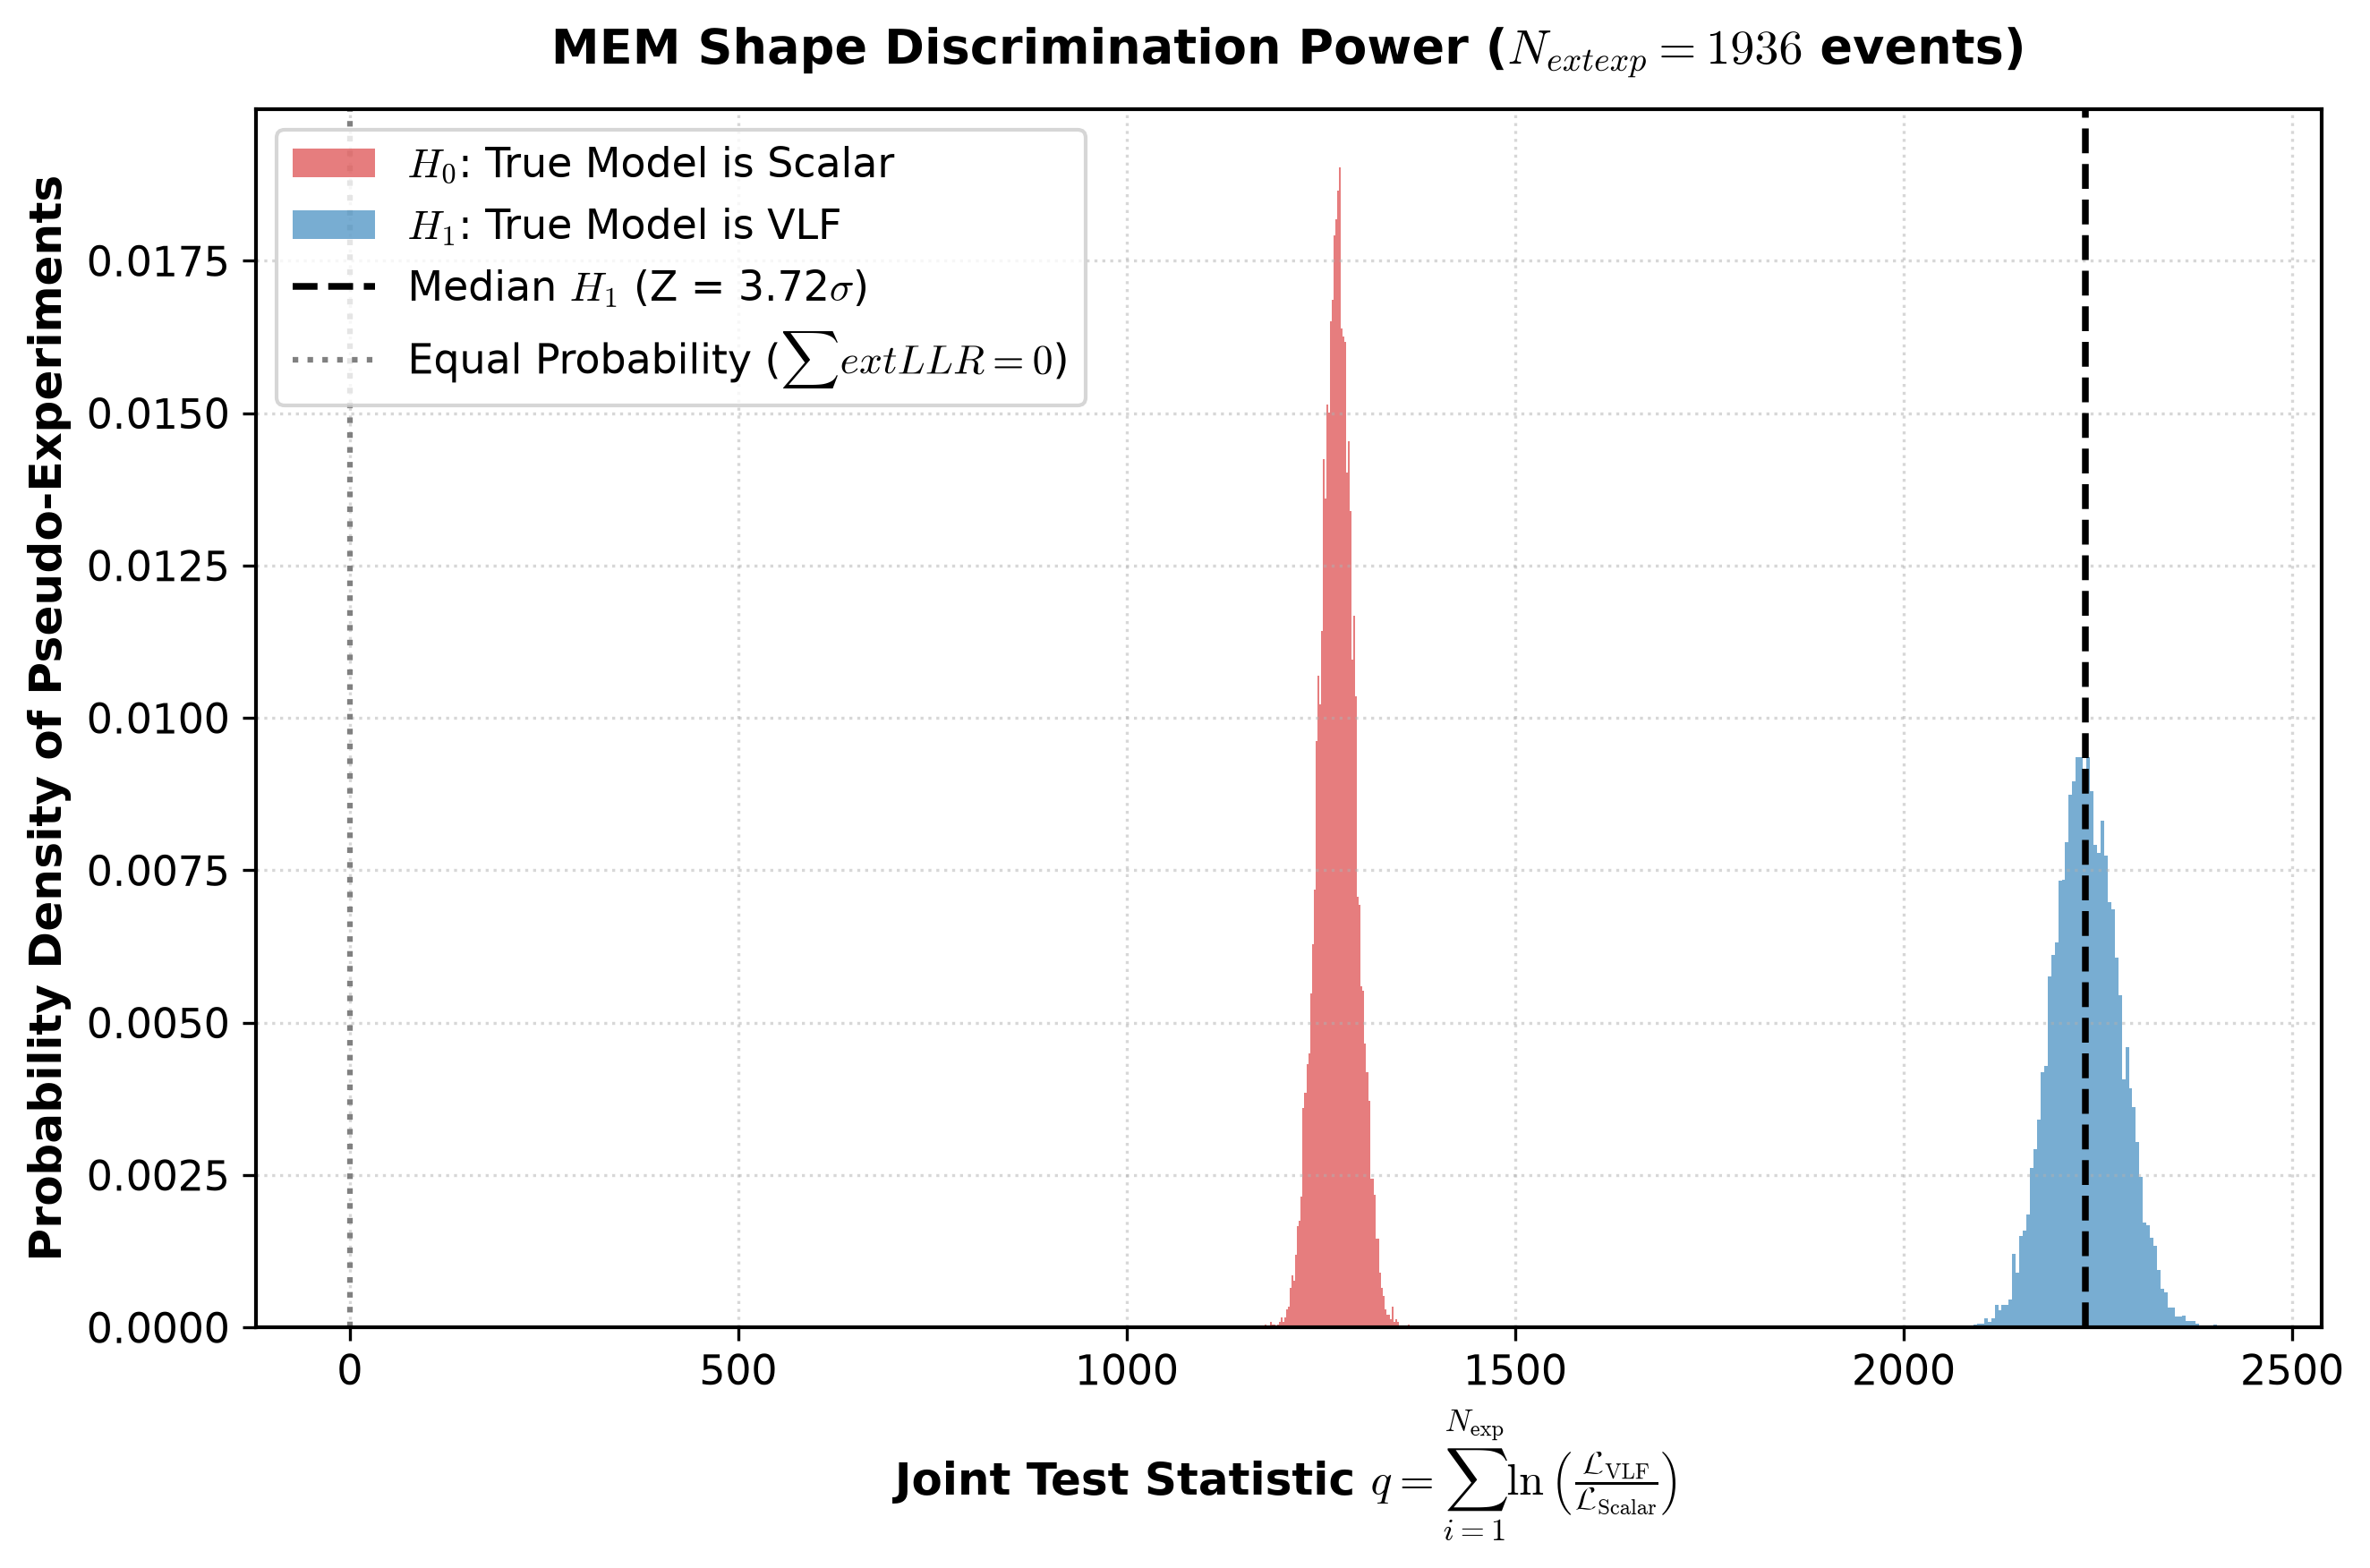

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================
# 1. LOAD DATA & CONFIGURATION
# ==========================================
csv_path = "/home/vinicius/UnfoldingBSMttbar/MEM_Likelihoods_with_LLR.csv.gz"
print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

# --- EXPERIMENTAL PARAMETERS ---
# Set how many signal events you expect to observe in a real LHC run
# e.g., N_exp = 500 events after cuts for a given integrated luminosity
N_EXP = 1936         # Expected observed events per experiment
N_TOYS = 10000      # Number of pseudo-experiments to simulate

# We test VLF against Scalar using our pre-computed column
llr_col = 'LLR_VLF_vs_Scalar'
llr_data = df[llr_col].values

# ==========================================
# 2. ASYMPTOTIC ESTIMATE (CLT)
# ==========================================
# When Scalar is true (H0), the LLR tends to be negative.
# When VLF is true (H1), the LLR tends to be positive.
mu_per_event = np.mean(llr_data)
std_per_event = np.std(llr_data)

# By the Central Limit Theorem, for N_EXP events:
mu_total = N_EXP * mu_per_event
std_total = np.sqrt(N_EXP) * std_per_event

# Asymptotic significance estimate testing against LLR = 0
z_asymptotic = np.abs(mu_total) / std_total
print(f"\n--- Asymptotic Analytical Estimate (for N_exp = {N_EXP} events) ---")
print(f"Expected per-event LLR mean: {mu_per_event:.4f} | std: {std_per_event:.4f}")
print(f"Expected joint LLR mean:     {mu_total:.2f} | std: {std_total:.2f}")
print(f"Estimated Significance:      {z_asymptotic:.2f} sigma")

# ==========================================
# 3. TOY MONTE CARLO PSEUDO-EXPERIMENTS
# ==========================================
print(f"\nRunning {N_TOYS:,} Toy MC experiments sampling {N_EXP} events each...")

# To rigorously simulate H0 (Scalar true) vs H1 (VLF true) from a single kinematic pool,
# we reweight the sampling probabilities by the model likelihoods.
# Probability of pulling an event if Scalar is true is proportional to L_Scalar:
p_scalar = df['L_Scalar'].values / np.sum(df['L_Scalar'].values)

# Probability of pulling an event if VLF is true is proportional to L_VLF:
p_vlf = df['L_VLF'].values / np.sum(df['L_VLF'].values)

# Generate pseudo-experiments using fast NumPy vectorized matrix sampling
# Shape: (N_TOYS, N_EXP) -> sum along axis 1 gives total LLR per toy experiment
toys_H0  = np.random.choice(llr_data, size=(N_TOYS, N_EXP), p=p_scalar).sum(axis=1)
toys_H1    = np.random.choice(llr_data, size=(N_TOYS, N_EXP), p=p_vlf).sum(axis=1)

# ==========================================
# 4. COMPUTE EXACT P-VALUE AND SIGNIFICANCE
# ==========================================
# The median sensitivity of H1 testing against the H0 distribution
median_H1 = np.median(toys_H1)
p_value = np.mean(toys_H0 >= median_H1)  # Fraction of H0 toys leaking past H1 median

# Handle numerical limits if separation is total (p_value == 0)
if p_value == 0:
    p_value = 1.0 / N_TOYS
    print(f"\nExact p-value is smaller than 1/{N_TOYS}. Separation is extremely strong!")
    
z_toy = norm.ppf(1.0 - p_value)
print(f"Toy MC p-value:          {p_value:.6e}")
print(f"Toy MC Significance (Z): {z_toy:.2f} sigma")

# ==========================================
# 5. PLOT STATISTICAL SEPARATION CURVES
# ==========================================
plt.figure(figsize=(9, 6), dpi=300)

# Plot Null Hypothesis (Scalar)
plt.hist(toys_H0, bins=80, color='#d62728', alpha=0.6, density=True, label=r'$H_0$: True Model is Scalar')

# Plot Alternative Hypothesis (VLF)
plt.hist(toys_H1, bins=80, color='#1f77b4', alpha=0.6, density=True, label=r'$H_1$: True Model is VLF')

# Draw Median Reference Line
plt.axvline(median_H1, color='black', linestyle='--', linewidth=1.8, label=f'Median $H_1$ (Z = {z_toy:.2f}$\sigma$)')
plt.axvline(0, color='gray', linestyle=':', linewidth=1.5, label='Equal Probability ($\sum \text{LLR} = 0$)')

plt.xlabel(r'Joint Test Statistic $q = \sum_{i=1}^{N_{\text{exp}}} \ln\left(\frac{\mathcal{L}_{\text{VLF}}}{\mathcal{L}_{\text{Scalar}}}\right)$', fontsize=12, fontweight='bold')
plt.ylabel('Probability Density of Pseudo-Experiments', fontsize=12, fontweight='bold')
plt.title(f'MEM Shape Discrimination Power ($N_{{\text{{exp}}}} = {N_EXP}$ events)', fontsize=13, fontweight='bold', pad=12)

plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

output_plot = "/home/vinicius/UnfoldingBSMttbar/MEM_Significance_ToyMC.png"
plt.tight_layout()
plt.savefig(output_plot, dpi=300)
print(f"\nSaved significance separation plot to: {output_plot}")

plt.show()

In [29]:
# ==========================================
# 4. RANDOM 2->2 KINEMATIC PHASE SPACE GENERATOR
# ==========================================
def generate_random_ttbar_momenta(e_beam, m_top=172.5, seed=None):
    """
    Generates a valid, energy-momentum conserved 4-momentum array [E, px, py, pz]
    for a 2 -> 2 collision: ab -> t + tbar.
    """
    if seed is not None:
        np.random.seed(seed)
        
    # 1. Sample random parton momentum fractions x1, x2 above the ttbar threshold
    s_tot = (2.0 * e_beam)**2
    tau_min = (2.0 * m_top)**2 / s_tot
    
    # Sample x1 exponentially/uniformly and derive x2 above threshold
    x1 = np.random.uniform(np.sqrt(tau_min), 0.8)
    x2 = np.random.uniform(tau_min / x1, 0.8)
    
    s_hat = x1 * x2 * s_tot
    e_cm = np.sqrt(s_hat)
    
    # 2. Define incoming parton 4-momenta in the lab frame [E, px, py, pz]
    p1 = [x1 * e_beam, 0.0, 0.0,  x1 * e_beam]
    p2 = [x2 * e_beam, 0.0, 0.0, -x2 * e_beam]
    
    # 3. Generate top quark momenta in the center-of-mass (CM) frame
    p_mag_cm = np.sqrt((e_cm / 2.0)**2 - m_top**2)
    
    cos_theta = np.random.uniform(-0.9, 0.9)
    sin_theta = np.sqrt(1.0 - cos_theta**2)
    phi = np.random.uniform(0.0, 2.0 * np.pi)
    
    p3_cm = [
        e_cm / 2.0,
        p_mag_cm * sin_theta * np.cos(phi),
        p_mag_cm * sin_theta * np.sin(phi),
        p_mag_cm * cos_theta
    ]
    p4_cm = [
        e_cm / 2.0,
        -p3_cm[1],
        -p3_cm[2],
        -p3_cm[3]
    ]
    
    # 4. Boost outgoing top quarks along z-axis back to the laboratory frame
    beta_z = (x1 - x2) / (x1 + x2)
    gamma = 1.0 / np.sqrt(1.0 - beta_z**2)
    
    def boost_z(p_4vec):
        e, px, py, pz = p_4vec
        return [
            gamma * (e + beta_z * pz),
            px,
            py,
            gamma * (pz + beta_z * e)
        ]
        
    p3 = boost_z(p3_cm)
    p4 = boost_z(p4_cm)
    
    return [p1, p2, p3, p4], {
        "x1": x1, "x2": x2, 
        "s_hat": s_hat, "sqrt_s_hat": e_cm,
        "cos_theta_cm": cos_theta
    }

# ==========================================
# 5. SANITY CHECK: EVALUATE ALL MODELS
# ==========================================
print("Running Sanity Check: Matrix Element Evaluation...\n" + "="*65)

# 1. Initialize LHAPDF to get physical alpha_s at MU_R
try:
    pdf = lhapdf.mkPDF(PDF_NAME)
    alphas = pdf.alphasQ(MU_R)
    print(f"LHAPDF initialized successfully: PDF ID = {PDF_NAME}")
except Exception as e:
    # Fallback to the physical constant if LHAPDF data files are missing locally
    alphas = 0.088464
    print(f"LHAPDF fallback: Using default alpha_s(mu_R={MU_R} GeV) = {alphas}")

print(f"Renormalization Scale mu_R = {MU_R} GeV | alpha_s = {alphas:.6f}")

# 2. Generate a single random kinematic collision point
p_lab, kin_info = generate_random_ttbar_momenta(E_BEAM, m_top=172.5, seed=101)
p_fortran = invert_momenta(p_lab)

print(f"\nRandom Kinematic Phase-Space Point Generated:")
print(f" -> x1 = {kin_info['x1']:.4f} | x2 = {kin_info['x2']:.4f}")
print(f" -> sqrt(s_hat) = {kin_info['sqrt_s_hat']:.2f} GeV | cos(theta*) = {kin_info['cos_theta_cm']:.3f}\n")

# 3. Loop over all registries and evaluate |M|^2
results = []

for model_name, channels in models.items():
    for channel_name, mod_dict in channels.items():
        try:
            me_val = eval_full_me(mod_dict, p_fortran, alphas, MU_R2)
            status = "OK"
        except Exception as err:
            me_val = np.nan
            status = f"FAILED: {str(err)[:30]}..."
            
        results.append({
            "Model": model_name,
            "Subprocess": channel_name,
            "|M|^2 (Raw Value)": f"{me_val:.6e}" if not np.isnan(me_val) else "NaN",
            "Status": status
        })

# ==========================================
# 6. DISPLAY COMPARISON TABLE
# ==========================================
df_sanity = pd.DataFrame(results)
print(df_sanity.to_string(index=False))
print("\n" + "="*65)
print("[✓] Sanity check complete. Check that all status flags read 'OK' and values are strictly non-NaN.")

Running Sanity Check: Matrix Element Evaluation...
LHAPDF initialized successfully: PDF ID = 244600
Renormalization Scale mu_R = 1000.0 GeV | alpha_s = 0.088464

Random Kinematic Phase-Space Point Generated:
 -> x1 = 0.4260 | x2 = 0.4572
 -> sqrt(s_hat) = 5737.18 GeV | cos(theta*) = -0.849

LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
 Model Subprocess |M|^2 (Raw Value) Status
   VLF P0_uux_ttx     -1.956575e-03     OK
   VLF  P2_gg_ttx     -9.467630e-04     OK
Scalar P0_uux_ttx     -3.345906e-04     OK
Scalar  P2_gg_ttx     -1.110298e-03     OK
Zprime P1_uux_ttx      4.727518e-01     OK
Zprime P1_ccx_ttx      4.727253e-01     OK
Zprime P1_ddx_ttx      4.727518e-01     OK
Zprime P1_ssx_ttx      4.727253e-01     OK
Zprime  P1_gg_ttx      2.117983e+00     OK

[✓] Sanity check complete. Check that all status flags read 'OK' and values are strictly non-NaN.
NNPDF23_nlo_as_0118_qed PDF set, member #0, ver

In [4]:
import sys
import os
import glob
import importlib.util
import numpy as np
import pandas as pd
import lhapdf

# ==========================================
# 1. DEFINE YOUR SPECIFIC PHASE SPACE POINT
# ==========================================
# Format: [E, px, py, pz] in GeV
# Center-of-mass energy sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
p_user_lab = [
    [5.0000000E+02,  0.0000000E+00,   0.0000000E+00,  5.0000000E+02],
    [5.0000000E+02,  0.0000000E+00,   0.0000000E+00, -5.0000000E+02],
    [5.0000000E+02, -0.1773893E-306, -0.1736952E+03, -0.4361720E+03],
    [5.0000000E+02,  0.1773893E-306,  0.1736952E+03,  0.4361720E+03]
]

# Transpose array to match Fortran memory layout (4 x N_particles)
def invert_momenta(p):
    new_p = [[0] * len(p) for _ in range(len(p[0]))]
    for i, onep in enumerate(p):
        for j, x in enumerate(onep):
            new_p[j][i] = x
    return new_p

p_fortran = invert_momenta(p_user_lab)

# ==========================================
# 2. DYNAMIC COMPONENT UNPACKER
# ==========================================
def eval_full_me_components(module_dict, p_fortran, alphas, scale2, nhel=-1):
    mod = module_dict["module"]
    subproc_path = module_dict["path"]
    mod_attrs = dir(mod)
    
    lo_eval = [a for a in mod_attrs if a.endswith('get_value')]
    nlo_eval = [a for a in mod_attrs if a.endswith('get_me')]
    
    original_cwd = os.getcwd()
    try:
        os.chdir(subproc_path)
        
        # --- CASE 1: LEADING ORDER (get_value) ---
        if lo_eval:
            val = getattr(mod, lo_eval[0])(p_fortran, alphas, nhel)
            val_list = [float(x) for x in np.ravel(val)]
            born_val = val_list[0] if len(val_list) > 0 else 0.0
            
            return {
                "Type": "LO (Tree)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": 0.0,
                "Single Pole (1/eps)": 0.0,
                "Double Pole (1/eps^2)": 0.0,
                "MadLoop Code": "N/A",
                "Raw Array": val_list
            }
            
        # --- CASE 2: NEXT-TO-LEADING ORDER / LOOP (get_me) ---
        elif nlo_eval:
            res, ret_code = getattr(mod, nlo_eval[0])(p_fortran, alphas, scale2, nhel)
            res_list = [float(x) for x in np.ravel(res)]
            
            # DYNAMIC CHECK: Did we apply the Fortran patch to this folder?
            if len(res_list) == 4:
                # Patched Wrapper! Array is exactly [Born, Finite, 1eps, 2eps]
                born_val   = res_list[0]
                finite_val = res_list[1]
                pole1_val  = res_list[2]
                pole2_val  = res_list[3]
            else:
                # Unpatched Wrapper (Original MadGraph). res_list[0] is the Finite term!
                born_val   = 0.0
                finite_val = res_list[0] if len(res_list) > 0 else 0.0
                pole1_val  = res_list[1] if len(res_list) > 1 else 0.0
                pole2_val  = res_list[2] if len(res_list) > 2 else 0.0
            
            return {
                "Type": "NLO (MadLoop)",
                "Born (|M0|^2)": born_val,
                "Finite 1-Loop": finite_val,
                "Single Pole (1/eps)": pole1_val,
                "Double Pole (1/eps^2)": pole2_val,
                "MadLoop Code": str(int(ret_code)) if isinstance(ret_code, (int, float, np.number)) else str(ret_code),
                "Raw Array": res_list
            }
        else:
            raise AttributeError("Module defines neither get_value nor get_me!")
            
    finally:
        os.chdir(original_cwd)

# ==========================================
# 3. EVALUATE ALL MODELS FOR THIS EXACT POINT
# ==========================================
print("Evaluating Specific Phase Space Point Across Models...\n" + "="*85)
print(f"Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV")
print(f"Top-Quark Momentum: p3 = [{p_user_lab[2][0]:.1f}, {p_user_lab[2][1]:.2e}, {p_user_lab[2][2]:.1f}, {p_user_lab[2][3]:.1f}] GeV\n")

# Initialize LHAPDF to get physical alpha_s at MU_R = 1000 GeV
try:
    pdf = lhapdf.mkPDF(PDF_NAME)
    alphas = pdf.alphasQ(MU_R)
except Exception:
    alphas = 0.088464 # Physical fallback

results_detailed = []

for model_name, channels in models.items():
    for channel_name, mod_dict in channels.items():
        try:
            comps = eval_full_me_components(mod_dict, p_fortran, alphas, MU_R2)
            status = "OK"
        except Exception as err:
            # Fixed dictionary keys in exception block to match perfectly
            comps = {
                "Type": "ERROR", "Born (|M0|^2)": np.nan, "Finite 1-Loop": np.nan,
                "Single Pole (1/eps)": np.nan, "Double Pole (1/eps^2)": np.nan,
                "MadLoop Code": "ERR", "Raw Array": []
            }
            status = f"FAIL: {str(err)[:20]}"
            
        results_detailed.append({
            "Model": model_name,
            "Channel": channel_name,
            "Type": comps["Type"],
            "Born (|M0|^2)": f"{comps['Born (|M0|^2)']:.4e}",
            "Finite 1-Loop": f"{comps['Finite 1-Loop']:.4e}",
            "Single Pole (1/eps)": f"{comps['Single Pole (1/eps)']:.4e}",
            "Double Pole (1/eps^2)": f"{comps['Double Pole (1/eps^2)']:.4e}",
            "MadLoop Code": comps["MadLoop Code"],
            "Status": status
        })

# ==========================================
# 4. DISPLAY FULL COMPONENT TABLE
# ==========================================
df_components = pd.DataFrame(results_detailed)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print(df_components.to_string(index=False))
print("="*85)

Evaluating Specific Phase Space Point Across Models...
Kinematic Point: sqrt(s_hat) = 1000.0 GeV | m_top = 172.0 GeV
Top-Quark Momentum: p3 = [500.0, -1.77e-307, -173.7, -436.2] GeV

LHAPDF 6.5.5 loading /home/vinicius/MG5/HEPTools/lhapdf6_py3//share/LHAPDF/NNPDF23_nlo_as_0118_qed/NNPDF23_nlo_as_0118_qed_0000.dat
NNPDF23_nlo_as_0118_qed PDF set, member #0, version 4; LHAPDF ID = 244600
 Model    Channel          Type Born (|M0|^2) Finite 1-Loop Single Pole (1/eps) Double Pole (1/eps^2) MadLoop Code Status
   VLF P0_uux_ttx NLO (MadLoop)    9.1831e-01    4.2780e-04          0.0000e+00            0.0000e+00          216     OK
   VLF  P2_gg_ttx NLO (MadLoop)    4.9912e+00    9.8105e-05         -1.2121e-16            0.0000e+00          216     OK
Scalar P0_uux_ttx NLO (MadLoop)    9.1831e-01    2.3915e-04          3.8549e-18            0.0000e+00          216     OK
Scalar  P2_gg_ttx NLO (MadLoop)    4.9912e+00   -1.6476e-04         -1.8922e-16            0.0000e+00          216     OK
Z

In [41]:
import sys
import os
import glob
import importlib.util
import importlib

# Load just the uux -> ttx VLF library to inspect it
vlf_path = "/home/vinicius/EFT_ToyModel/processFolders/UV_BSM/MatrixElements/SubProcesses/P0_uux_ttx"
so_file = glob.glob(os.path.join(vlf_path, "*matrix*.so"))[0]
lib_name = os.path.basename(so_file).split(".")[0]

spec = importlib.util.spec_from_file_location(lib_name, so_file)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

print(f"--- Exposed Functions in {lib_name} ---")
for attr in dir(mod):
    if not attr.startswith("_"):
        print(f" -> {attr}")

--- Exposed Functions in matrix_VLF_P0_uux_ttx ---
 -> couplings
 -> get_me
 -> initialise
 -> masses
 -> ml5_0_chosen_loop_sqso
 -> rscale
 -> strong
 -> weak
 -> widths
